# Regime-Shift: Macro-Aware Tactical Allocation Engine
## Performance Analysis

This notebook performs analysis exclusively; no model refitting occurs at this stage.

**Scope:**
- Loading of `walkfwd_integration` results
- Publication-quality chart generation for presentation purposes
- Return decomposition into passive (beta) and active (regime-timing) components
- Regime-conditional risk/return analysis
- Soft-blend probability visualization and Crisis-timing analysis
- v1 versus v2 improvement summary

**Inputs:** `data/stage5/` (`walkfwd_integration` output)
**Outputs:** `data/stage6/` — charts, tables, and presentation-ready assets

In [1]:
import json, warnings
from pathlib import Path

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.colors import TwoSlopeNorm
from scipy import stats

warnings.filterwarnings("ignore")
pd.options.display.float_format = "{:,.4f}".format

# Project paths
import os
PROJECT_DIR = Path(os.environ.get("REGIME_SHIFT_PROJECT_DIR", Path.cwd()))
DATA_DIR    = PROJECT_DIR / "data"
STAGE5_DIR  = DATA_DIR / "stage5"
STAGE6_DIR  = DATA_DIR / "stage6"
STAGE6_DIR.mkdir(parents=True, exist_ok=True)

# Shared style constants
BG       = "#0F1117"
AX_BG    = "#1A1D27"
GRID_COL = "#262840"
TEXT     = "#DDDDEE"
MUTED    = "#888899"
PALETTE  = {
    "REGIME-SHIFT"  : "#2ECC71",
    "NIFTYBEES B&H" : "#3498DB",
    "Equal Weight"  : "#F39C12",
    "60/40 India"   : "#9B59B6",
    "Bull"          : "#27AE60",
    "Crisis"        : "#C0392B",
}

def style_ax(ax, grid=True):
    ax.set_facecolor(AX_BG)
    ax.tick_params(colors=MUTED, labelsize=8)
    ax.spines[:].set_color(GRID_COL)
    for lb in ax.get_xticklabels() + ax.get_yticklabels():
        lb.set_color(MUTED)
    if grid:
        ax.grid(axis="y", color=GRID_COL, lw=0.5, alpha=0.6)

def title(ax, t, fs=10):
    ax.set_title(t, color=TEXT, fontsize=fs, fontweight="bold", pad=6)

print("✓ Imports OK")
print(f"  Walk-Forward Integration data: {STAGE5_DIR}")
print(f"  Performance Analysis out : {STAGE6_DIR}")

✓ Imports OK
  Walk-Forward Integration data: /Users/kushagraverma/Downloads/test-main-formalized 2/data/stage5
  Performance Analysis out : /Users/kushagraverma/Downloads/test-main-formalized 2/data/stage6


In [2]:
# Load walk-forward results
wf = pd.read_parquet(STAGE5_DIR / "walkforward_results.parquet")
wf.index = pd.to_datetime(wf.index)
print(f"✓ Walk-forward results: {wf.shape}  ({wf.index[0].date()} → {wf.index[-1].date()})")

# Load return series
all_rets = pd.read_csv(STAGE5_DIR / "all_returns.csv", index_col=0, parse_dates=True)
strategy_rets = all_rets["strategy"]
bh_rets       = all_rets["niftybees_bh"]
ew_rets       = all_rets["equal_weight"]
india_6040    = all_rets["india_6040"]
print(f"✓ Return series: {all_rets.shape}")

# Load performance summary
perf_df = pd.read_csv(STAGE5_DIR / "performance_summary.csv", index_col=0)
print(f"✓ Performance summary loaded")

# Load metadata
with open(STAGE5_DIR / "metadata.json") as f:
    meta5 = json.load(f)

# RF rate (from walkfwd_integration config)
RF_ANNUAL  = 0.065
RF_MONTHLY = (1 + RF_ANNUAL) ** (1/12) - 1
ASSETS     = meta5["assets"]

print()
print("KEY NUMBERS FROM WALK-FORWARD INTEGRATION:")
print(perf_df.to_string())

# v1 reference numbers (from walkfwd_integration v1 run)
V1_REF = {
    "CAGR"   : 0.097,
    "Sharpe" : 0.356,
    "MaxDD"  : -0.119,
    "Calmar" : 0.814,
    "AvgTC"  : 14.6,    # bps/month round-trip
}
V2_ACT = {
    "CAGR"   : float(strategy_rets.dropna().add(1).prod()**(12/len(strategy_rets.dropna())) - 1),
    "Sharpe" : float((strategy_rets.mean() - RF_MONTHLY) / (strategy_rets.std() + 1e-10) * np.sqrt(12)),
    "MaxDD"  : float(((strategy_rets.add(1).cumprod() / strategy_rets.add(1).cumprod().cummax()) - 1).min()),
    "Calmar" : 0.0,
    "AvgTC"  : float(wf["round_trip_bps"].mean()),
}
V2_ACT["Calmar"] = V2_ACT["CAGR"] / abs(V2_ACT["MaxDD"]) if V2_ACT["MaxDD"] != 0 else 0
print()
print("v1 vs v2 snapshot:")
for k in ["CAGR","Sharpe","MaxDD","Calmar"]:
    v1, v2 = V1_REF[k], V2_ACT[k]
    arrow = "↑" if (v2 > v1) == (k != "MaxDD") else "↓"
    print(f"  {k:8s}: v1={v1:.3f}  v2={v2:.3f}  {arrow}")

✓ Walk-forward results: (107, 27)  (2015-01-29 → 2023-11-30)
✓ Return series: (107, 4)
✓ Performance summary loaded

KEY NUMBERS FROM WALK-FORWARD INTEGRATION:
                CAGR Ann. Vol  Sharpe  Sortino  Max DD  Calmar Win Rate  Months
Strategy                                                                       
REGIME-SHIFT   12.1%     8.9%  0.6260   1.0380   -7.7%  1.5750      57%     107
NIFTYBEES B&H  11.6%    16.9%  0.3670   0.3710  -31.0%  0.3760      55%     107
Equal Weight   10.4%     8.8%  0.4570   0.6420  -12.5%  0.8340      53%     107
60/40 India    10.9%    10.3%  0.4480   0.5950  -15.8%  0.6910      54%     107

v1 vs v2 snapshot:
  CAGR    : v1=0.097  v2=0.121  ↑
  Sharpe  : v1=0.356  v2=0.626  ↑
  MaxDD   : v1=-0.119  v2=-0.077  ↓
  Calmar  : v1=0.814  v2=1.575  ↑


In [3]:
# Full performance metrics helper
def perf(r, label):
    r = r.dropna()
    n = len(r)
    cagr    = (1+r).prod()**(12/n) - 1
    vol     = r.std() * np.sqrt(12)
    sharpe  = (r.mean() - RF_MONTHLY) / (r.std()+1e-10) * np.sqrt(12)
    down    = r[r < RF_MONTHLY]
    dd_std  = down.std() * np.sqrt(12) if len(down) else 1e-10
    sortino = (cagr - RF_ANNUAL) / (dd_std + 1e-10)
    cum     = (1+r).cumprod()
    mdd     = ((cum - cum.cummax()) / cum.cummax()).min()
    calmar  = cagr / abs(mdd) if mdd else 0
    var95   = float(np.percentile(r, 5))
    cvar95  = float(r[r <= var95].mean()) if (r <= var95).any() else var95
    win     = (r > RF_MONTHLY).mean()
    return dict(Strategy=label, CAGR=cagr, Vol=vol, Sharpe=sharpe, Sortino=sortino,
                MaxDD=mdd, Calmar=calmar, VaR95=var95, CVaR95=cvar95, WinRate=win, N=n)

rows = [perf(strategy_rets,"REGIME-SHIFT v2"), perf(bh_rets,"NIFTYBEES B&H"),
        perf(ew_rets,"Equal Weight"),   perf(india_6040,"60/40 India")]
ptbl = pd.DataFrame(rows).set_index("Strategy")

fmt = {
    "CAGR":"{:.1%}","Vol":"{:.1%}","Sharpe":"{:.3f}","Sortino":"{:.3f}",
    "MaxDD":"{:.1%}","Calmar":"{:.3f}","VaR95":"{:.2%}","CVaR95":"{:.2%}",
    "WinRate":"{:.0%}","N":"{:.0f}"
}
print("="*80)
print("PERFORMANCE TABLE  —  Jan 2015 → Nov 2023  (107 months)")
print("="*80)
for col,f in fmt.items():
    vals = "   ".join(f.format(ptbl.loc[s,col]) for s in ptbl.index)
    print(f"  {col:10s}: {vals}")
print("="*80)
print(f"  Sharpe advantage vs B&H : {ptbl.loc['REGIME-SHIFT v2','Sharpe'] - ptbl.loc['NIFTYBEES B&H','Sharpe']:+.3f}")
print(f"  DD protection vs B&H    : {ptbl.loc['NIFTYBEES B&H','MaxDD'] - ptbl.loc['REGIME-SHIFT v2','MaxDD']:+.1%}")
print(f"  Calmar advantage vs B&H : {ptbl.loc['REGIME-SHIFT v2','Calmar'] / ptbl.loc['NIFTYBEES B&H','Calmar']:.1f}x")

PERFORMANCE TABLE  —  Jan 2015 → Nov 2023  (107 months)
  CAGR      : 12.1%   11.6%   10.4%   10.9%
  Vol       : 8.9%   16.9%   8.8%   10.3%
  Sharpe    : 0.626   0.367   0.457   0.448
  Sortino   : 1.038   0.371   0.642   0.595
  MaxDD     : -7.7%   -31.0%   -12.5%   -15.8%
  Calmar    : 1.575   0.376   0.834   0.691
  VaR95     : -2.85%   -5.43%   -1.91%   -2.55%
  CVaR95    : -4.41%   -9.65%   -4.53%   -5.37%
  WinRate   : 57%   55%   53%   54%
  N         : 107   107   107   107
  Sharpe advantage vs B&H : +0.259
  DD protection vs B&H    : -23.2%
  Calmar advantage vs B&H : 4.2x


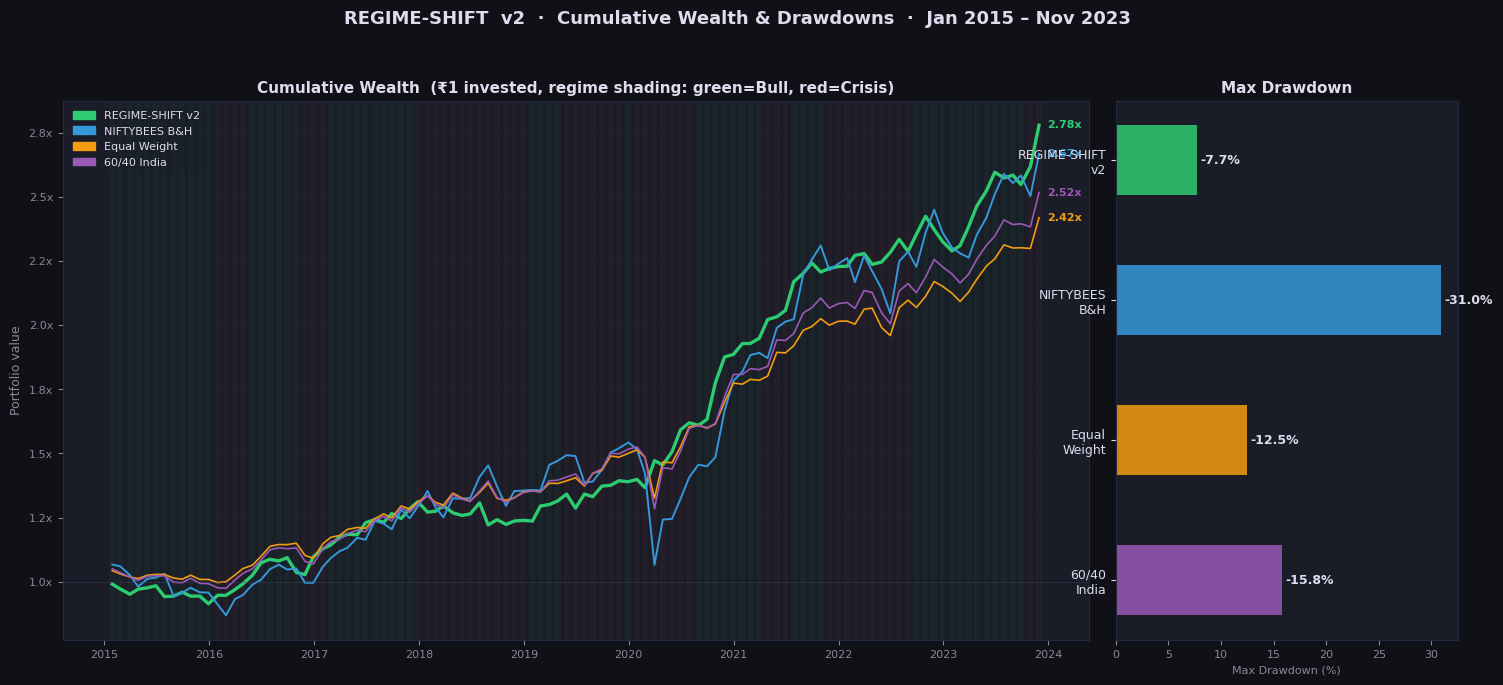

✓ chart_cumulative_wealth.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7), facecolor=BG,
    gridspec_kw={"width_ratios": [3, 1], "wspace": 0.04})
fig.suptitle("REGIME-SHIFT  v2  ·  Cumulative Wealth & Drawdowns  ·  Jan 2015 – Nov 2023",
             color=TEXT, fontsize=13, fontweight="bold", y=1.01)

STRATS = [
    ("REGIME-SHIFT v2", strategy_rets, "#2ECC71", 2.4),
    ("NIFTYBEES B&H",   bh_rets,       "#3498DB", 1.4),
    ("Equal Weight",    ew_rets,        "#F39C12", 1.2),
    ("60/40 India",     india_6040,     "#9B59B6", 1.2),
]

# Panel A: Cumulative wealth
ax1 = axes[0]; style_ax(ax1, grid=False)
ax1.grid(axis="y", color=GRID_COL, lw=0.5, alpha=0.5)

# Regime shading
for _, row in wf.iterrows():
    c = PALETTE.get(row["confirmed_regime"], "#444")
    ax1.axvspan(row.name - pd.DateOffset(days=10),
                row.name + pd.DateOffset(days=10),
                alpha=0.06, color=c, lw=0)

# Cumulative lines
idx = strategy_rets.index
for lbl, r, col, lw in STRATS:
    cum = (1 + r.reindex(idx).fillna(0)).cumprod()
    ax1.plot(cum.index, cum.values, label=lbl, color=col, lw=lw)

ax1.axhline(1, color="#444466", lw=0.7, ls=":")
title(ax1, "Cumulative Wealth  (₹1 invested, regime shading: green=Bull, red=Crisis)", 11)
ax1.set_ylabel("Portfolio value", color=MUTED, fontsize=9)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:.1f}x"))

# Final value annotations
for lbl, r, col, lw in STRATS:
    cum = (1 + r.reindex(idx).fillna(0)).cumprod()
    ax1.annotate(f"{cum.iloc[-1]:.2f}x",
                 xy=(cum.index[-1], cum.iloc[-1]),
                 xytext=(6, 0), textcoords="offset points",
                 color=col, fontsize=8, fontweight="bold", va="center")

# Legend
patches_leg = [mpatches.Patch(color=col, label=lbl) for lbl,_,col,_ in STRATS]
ax1.legend(handles=patches_leg, fontsize=8, framealpha=0.25, facecolor=AX_BG,
           edgecolor=GRID_COL, labelcolor=TEXT, loc="upper left")

# Panel B: Max drawdown bars
ax2 = axes[1]; style_ax(ax2, grid=False)
mdd_vals = [ptbl.loc["REGIME-SHIFT v2","MaxDD"],
            ptbl.loc["NIFTYBEES B&H","MaxDD"],
            ptbl.loc["Equal Weight","MaxDD"],
            ptbl.loc["60/40 India","MaxDD"]]
labels   = ["REGIME-SHIFT\nv2", "NIFTYBEES\nB&H", "Equal\nWeight", "60/40\nIndia"]
colors   = ["#2ECC71","#3498DB","#F39C12","#9B59B6"]
bars = ax2.barh(labels[::-1], [abs(v)*100 for v in mdd_vals[::-1]],
                color=colors[::-1], alpha=0.85, height=0.5)
for bar, val in zip(bars, mdd_vals[::-1]):
    ax2.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
             f"{val:.1%}", va="center", fontsize=9, color=TEXT, fontweight="bold")
title(ax2, "Max Drawdown", 11)
ax2.set_xlabel("Max Drawdown (%)", color=MUTED, fontsize=8)
ax2.tick_params(axis="y", labelsize=9, colors=TEXT)

plt.tight_layout()
plt.savefig(STAGE6_DIR/"chart_cumulative_wealth.png",
            dpi=160, bbox_inches="tight", facecolor=BG)
plt.show()
print("✓ chart_cumulative_wealth.png")

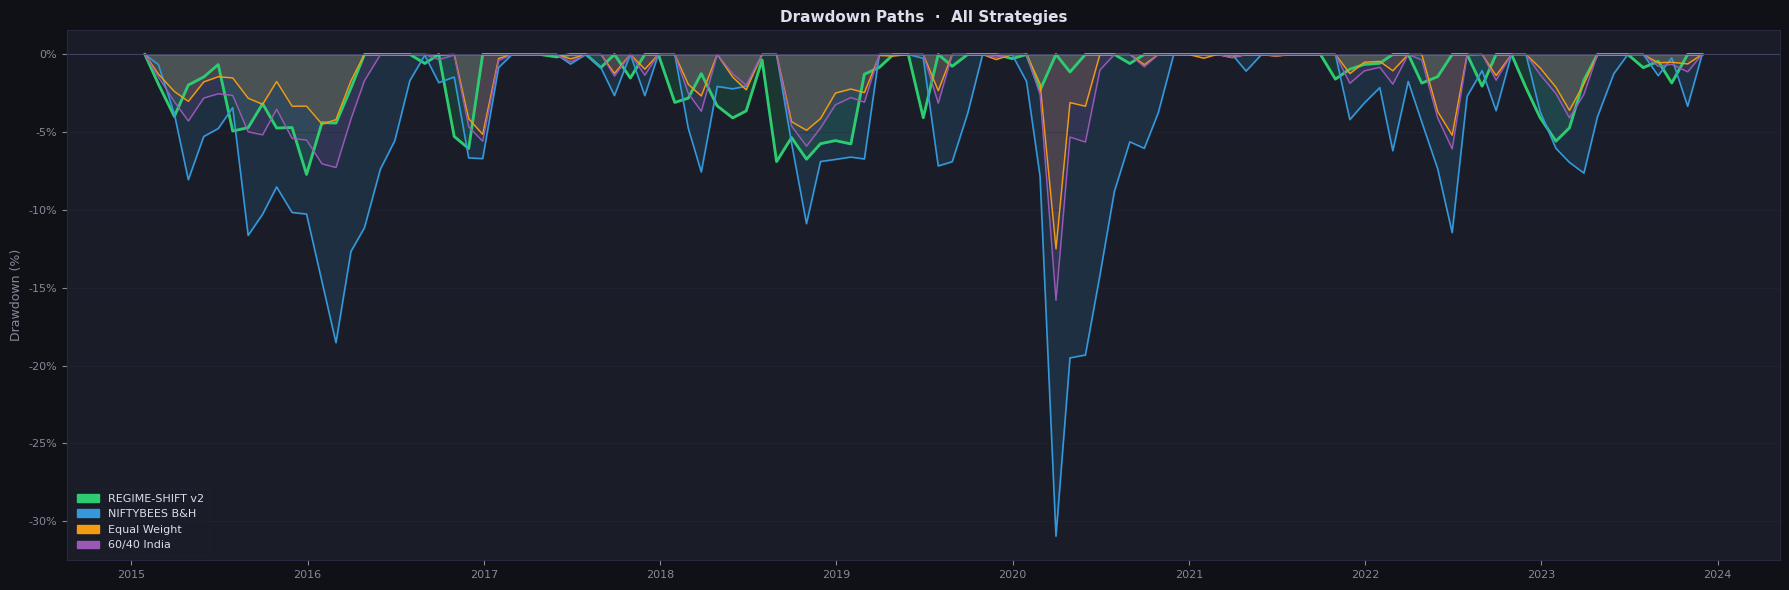

✓ chart_drawdowns.png


In [5]:
fig, ax = plt.subplots(figsize=(18, 6), facecolor=BG)
style_ax(ax)
title(ax, "Drawdown Paths  ·  All Strategies", 11)

for lbl, r, col, lw in STRATS:
    r2  = r.reindex(idx).fillna(0)
    cum = (1 + r2).cumprod()
    dd  = (cum - cum.cummax()) / cum.cummax() * 100
    ax.fill_between(dd.index, dd.values, 0, alpha=0.15, color=col)
    ax.plot(dd.index, dd.values, color=col, lw=lw*0.85, label=lbl)

ax.axhline(0, color="#444466", lw=0.7)
ax.set_ylabel("Drawdown (%)", color=MUTED, fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:.0f}%"))

patches_leg = [mpatches.Patch(color=col, label=lbl) for lbl,_,col,_ in STRATS]
ax.legend(handles=patches_leg, fontsize=8, framealpha=0.25, facecolor=AX_BG,
          edgecolor=GRID_COL, labelcolor=TEXT, loc="lower left")

plt.tight_layout()
plt.savefig(STAGE6_DIR/"chart_drawdowns.png",
            dpi=160, bbox_inches="tight", facecolor=BG)
plt.show()
print("✓ chart_drawdowns.png")

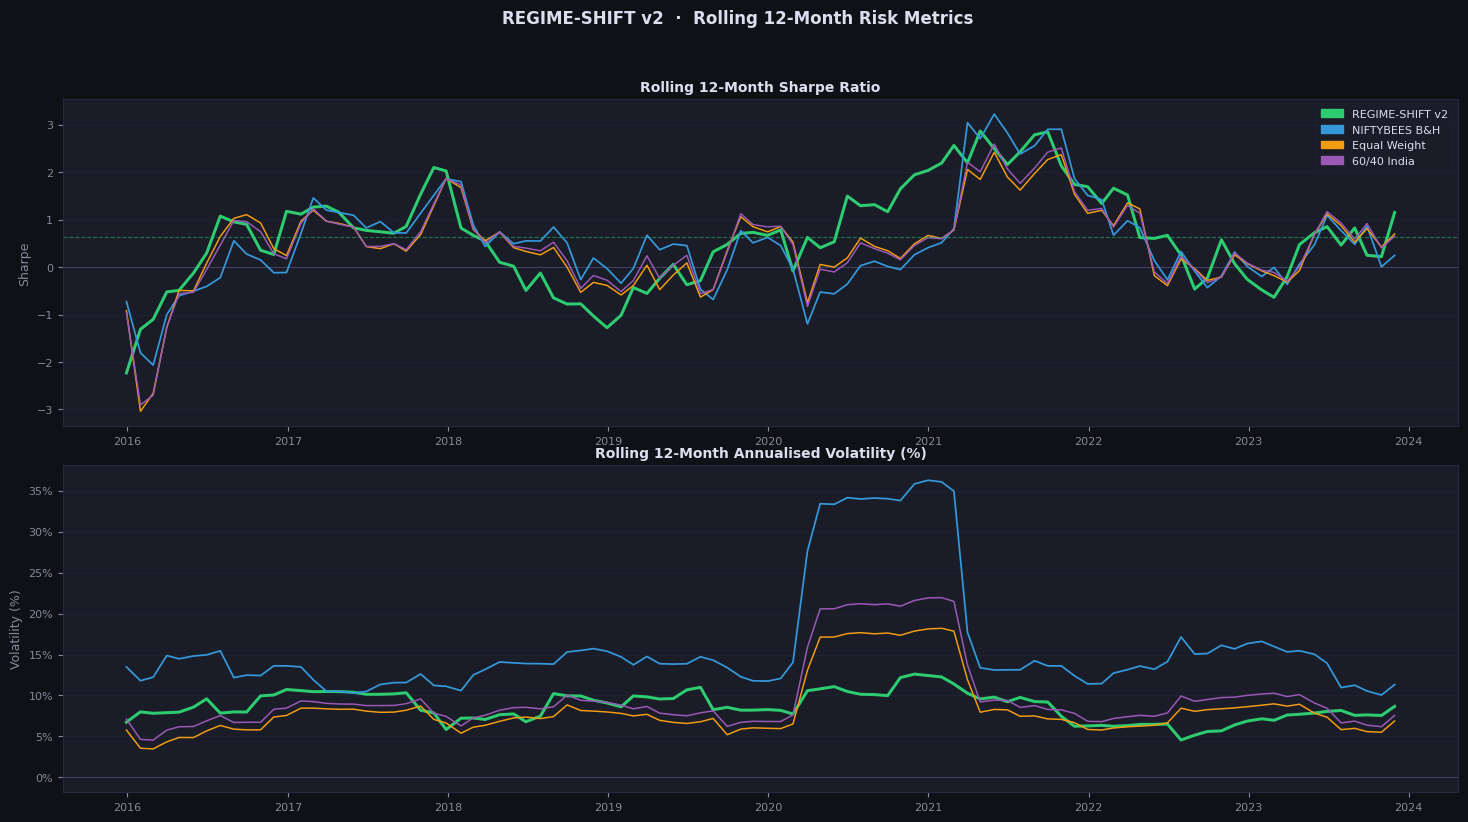

✓ chart_rolling_metrics.png


In [6]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 9), facecolor=BG,
    gridspec_kw={"hspace":0.12})
fig.suptitle("REGIME-SHIFT v2  ·  Rolling 12-Month Risk Metrics",
             color=TEXT, fontsize=12, fontweight="bold")

for ax in (ax1, ax2):
    style_ax(ax)
    ax.axhline(0, color="#444466", lw=0.7)

for lbl, r, col, lw in STRATS:
    r2 = r.reindex(idx).fillna(0)
    rs = ((r2.rolling(12).mean() - RF_MONTHLY) /
          (r2.rolling(12).std() + 1e-10)) * np.sqrt(12)
    ax1.plot(rs.index, rs.values, color=col, lw=lw*0.9, label=lbl)
    rv = r2.rolling(12).std() * np.sqrt(12) * 100
    ax2.plot(rv.index, rv.values, color=col, lw=lw*0.9)

title(ax1, "Rolling 12-Month Sharpe Ratio", 10)
ax1.set_ylabel("Sharpe", color=MUTED, fontsize=9)
ax1.axhline(ptbl.loc["REGIME-SHIFT v2","Sharpe"], color="#2ECC71",
            lw=0.8, ls="--", alpha=0.5, label="RS full-period avg")

patches_leg = [mpatches.Patch(color=col, label=lbl) for lbl,_,col,_ in STRATS]
ax1.legend(handles=patches_leg, fontsize=8, framealpha=0.25, facecolor=AX_BG,
           edgecolor=GRID_COL, labelcolor=TEXT)

title(ax2, "Rolling 12-Month Annualised Volatility (%)", 10)
ax2.set_ylabel("Volatility (%)", color=MUTED, fontsize=9)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:.0f}%"))

plt.tight_layout()
plt.savefig(STAGE6_DIR/"chart_rolling_metrics.png",
            dpi=160, bbox_inches="tight", facecolor=BG)
plt.show()
print("✓ chart_rolling_metrics.png")

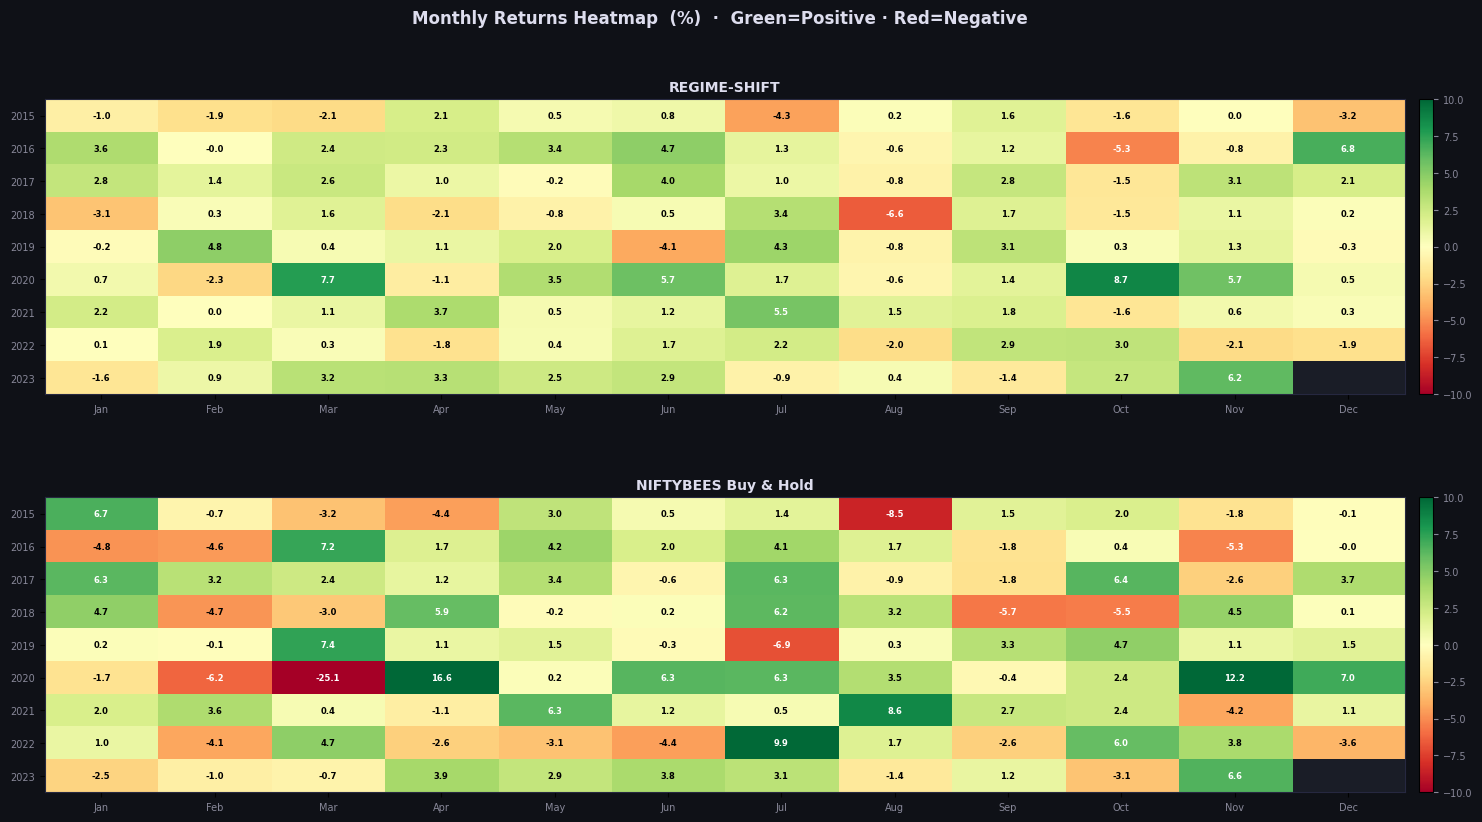

✓ chart_return_heatmap.png


In [7]:
def calendar_heatmap(ret_series, label, ax, vmin=-10, vmax=10):
    r   = ret_series.dropna() * 100
    df  = pd.DataFrame({"val": r, "year": r.index.year, "month": r.index.month})
    piv = df.pivot_table(index="year", columns="month", values="val")
    piv = piv.reindex(columns=range(1,13))
    mon = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
    norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
    im = ax.imshow(piv.values, cmap="RdYlGn", norm=norm, aspect="auto")
    ax.set_xticks(range(12)); ax.set_xticklabels(mon, fontsize=7, color=MUTED)
    ax.set_yticks(range(len(piv))); ax.set_yticklabels(piv.index, fontsize=7, color=MUTED)
    ax.spines[:].set_color(GRID_COL)
    for i, yr in enumerate(piv.index):
        for j, mo in enumerate(range(1, 13)):
            v = piv.loc[yr, mo] if mo in piv.columns and not pd.isna(piv.loc[yr, mo]) else np.nan
            if not np.isnan(v if v is not None else np.nan):
                ax.text(j, i, f"{v:.1f}", ha="center", va="center",
                        fontsize=6, color="black" if abs(v) < 5 else "white", fontweight="bold")
    ax.set_facecolor(AX_BG)
    title(ax, label, 10)
    return im

fig, axes = plt.subplots(2, 1, figsize=(18, 9), facecolor=BG,
    gridspec_kw={"hspace": 0.35})
fig.suptitle("Monthly Returns Heatmap  (%)  ·  Green=Positive · Red=Negative",
             color=TEXT, fontsize=12, fontweight="bold")

im1 = calendar_heatmap(strategy_rets, "REGIME-SHIFT", axes[0])
im2 = calendar_heatmap(bh_rets, "NIFTYBEES Buy & Hold", axes[1])

plt.colorbar(im1, ax=axes[0], orientation="vertical", pad=0.01,
             fraction=0.015).ax.tick_params(labelsize=7, colors=MUTED)
plt.colorbar(im2, ax=axes[1], orientation="vertical", pad=0.01,
             fraction=0.015).ax.tick_params(labelsize=7, colors=MUTED)

plt.savefig(STAGE6_DIR/"chart_return_heatmap.png",
            dpi=160, bbox_inches="tight", facecolor=BG)
plt.show()
print("✓ chart_return_heatmap.png")

In [8]:
print("REGIME-CONDITIONAL PERFORMANCE")
print("="*60)

for regime in ["Bull", "Crisis"]:
    mask  = wf["confirmed_regime"] == regime
    sub_r = strategy_rets.reindex(wf.index[mask]).dropna()
    sub_n = bh_rets.reindex(wf.index[mask]).dropna()
    if len(sub_r) == 0:
        continue
    n  = len(sub_r)
    rs_cagr = (1+sub_r).prod()**(12/n)-1 if n >= 3 else np.nan
    bh_cagr = (1+sub_n).prod()**(12/n)-1 if n >= 3 else np.nan
    rs_vol  = sub_r.std()*np.sqrt(12)
    bh_vol  = sub_n.std()*np.sqrt(12)
    avg_pc  = wf.loc[mask,"P_crisis"].mean()
    print(f"\n  {regime.upper()} REGIME  ({n} months, avg P(Crisis)={avg_pc:.2f})")
    print(f"  {'':25s}  {'REGIME-SHIFT':>14}  {'NIFTYBEES B&H':>14}")
    print(f"  {'CAGR':25s}  {rs_cagr:>13.1%}  {bh_cagr:>13.1%}")
    print(f"  {'Ann. Vol':25s}  {rs_vol:>13.1%}  {bh_vol:>13.1%}")
    print(f"  {'Nifty ↑ months':25s}  {(sub_n>0).mean():>13.0%}  {'(reference)':>14}")
    print(f"  {'Avg monthly return':25s}  {sub_r.mean():>13.2%}  {sub_n.mean():>13.2%}")
    print(f"  {'Worst month':25s}  {sub_r.min():>13.1%}  {sub_n.min():>13.1%}")

print()
print("  CRISIS TIMING ACCURACY:")
crisis_mask = wf["confirmed_regime"] == "Crisis"
bull_mask   = wf["confirmed_regime"] == "Bull"
nifty_ret   = bh_rets.reindex(wf.index).fillna(0)
crisis_acc  = (nifty_ret[crisis_mask] < 0).mean()
bull_acc    = (nifty_ret[bull_mask]   > 0).mean()
print(f"    Crisis months where Nifty fell : {crisis_acc:.0%}")
print(f"    Bull   months where Nifty rose : {bull_acc:.0%}")
print(f"    False positives (Crisis + Nifty rose)   : {(nifty_ret[crisis_mask] > 0).sum()} months")
print(f"    False negatives (Bull   + Nifty fell)   : {(nifty_ret[bull_mask]   < 0).sum()} months")

REGIME-CONDITIONAL PERFORMANCE

  BULL REGIME  (58 months, avg P(Crisis)=0.05)
                               REGIME-SHIFT   NIFTYBEES B&H
  CAGR                               11.0%          19.9%
  Ann. Vol                            8.7%          12.1%
  Nifty ↑ months                       67%     (reference)
  Avg monthly return                 0.90%          1.58%
  Worst month                        -5.3%          -8.5%

  CRISIS REGIME  (49 months, avg P(Crisis)=0.56)
                               REGIME-SHIFT   NIFTYBEES B&H
  CAGR                               13.5%           2.6%
  Ann. Vol                            9.3%          21.2%
  Nifty ↑ months                       57%     (reference)
  Avg monthly return                 1.10%          0.40%
  Worst month                        -6.6%         -25.1%

  CRISIS TIMING ACCURACY:
    Crisis months where Nifty fell : 43%
    Bull   months where Nifty rose : 67%
    False positives (Crisis + Nifty rose)   : 28 months
    

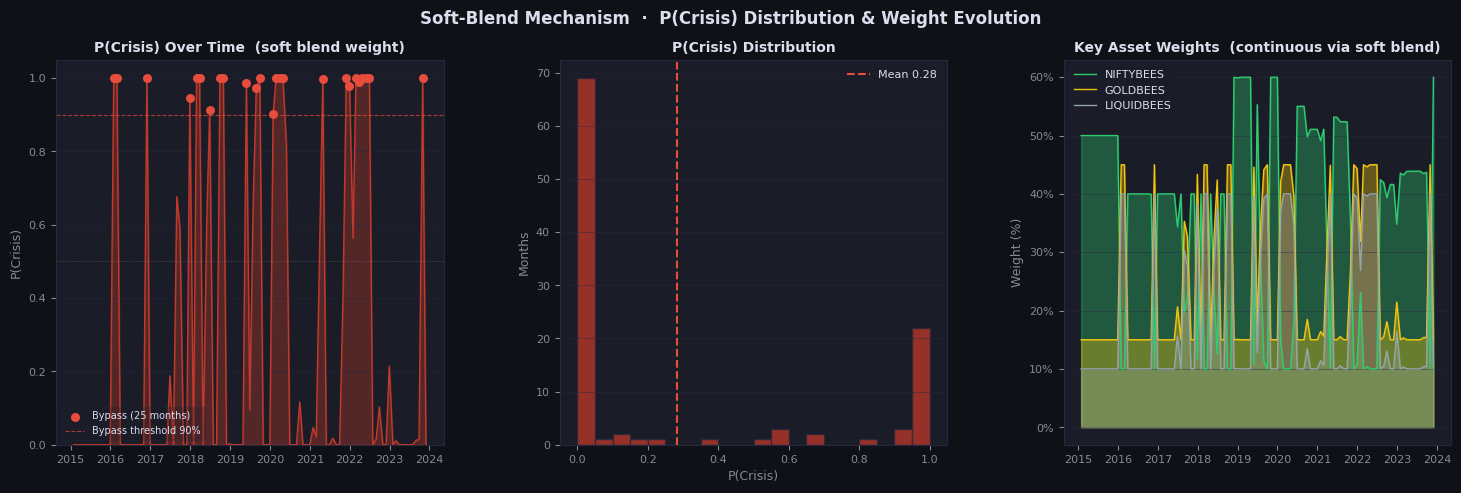

✓ chart_soft_blend.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor=BG,
    gridspec_kw={"wspace": 0.3})
fig.suptitle("Soft-Blend Mechanism  ·  P(Crisis) Distribution & Weight Evolution",
             color=TEXT, fontsize=12, fontweight="bold")

# Panel 1: P(Crisis) over time
ax = axes[0]; style_ax(ax)
pc = wf["P_crisis"]
ax.fill_between(wf.index, pc.values, 0, alpha=0.35, color="#C0392B")
ax.plot(wf.index, pc.values, color="#C0392B", lw=1.0)
# Magnitude bypass months
bypass_dates = wf.index[wf["magnitude_bypass"]]
ax.scatter(bypass_dates, pc.reindex(bypass_dates),
           color="#E74C3C", s=30, zorder=5, label=f"Bypass ({len(bypass_dates)} months)")
ax.axhline(0.90, color="#E74C3C", lw=0.8, ls="--", alpha=0.7, label="Bypass threshold 90%")
ax.axhline(0.50, color="#888",    lw=0.6, ls=":",  alpha=0.5)
title(ax, "P(Crisis) Over Time  (soft blend weight)", 10)
ax.set_ylabel("P(Crisis)", color=MUTED, fontsize=9)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=7, framealpha=0.25, facecolor=AX_BG,
          edgecolor=GRID_COL, labelcolor=TEXT)

# Panel 2: P(Crisis) distribution histogram
ax = axes[1]; style_ax(ax)
ax.hist(wf["P_crisis"], bins=20, color="#C0392B", alpha=0.75, edgecolor=GRID_COL)
ax.axvline(wf["P_crisis"].mean(), color="#E74C3C", lw=1.5, ls="--",
           label=f"Mean {wf['P_crisis'].mean():.2f}")
title(ax, "P(Crisis) Distribution", 10)
ax.set_xlabel("P(Crisis)", color=MUTED, fontsize=9)
ax.set_ylabel("Months", color=MUTED, fontsize=9)
ax.legend(fontsize=8, framealpha=0.25, facecolor=AX_BG,
          edgecolor=GRID_COL, labelcolor=TEXT)

# Panel 3: NIFTYBEES weight over time (shows soft blend continuity)
ax = axes[2]; style_ax(ax)
ax.fill_between(wf.index, wf["w_NIFTYBEES"].values * 100, alpha=0.35, color="#2ECC71")
ax.plot(wf.index, wf["w_NIFTYBEES"].values * 100, color="#2ECC71", lw=1.0, label="NIFTYBEES")
ax.fill_between(wf.index, wf["w_GOLDBEES"].values * 100, alpha=0.35, color="#F1C40F")
ax.plot(wf.index, wf["w_GOLDBEES"].values * 100, color="#F1C40F", lw=1.0, label="GOLDBEES")
ax.fill_between(wf.index, wf["w_LIQUIDBEES"].values * 100, alpha=0.35, color="#95A5A6")
ax.plot(wf.index, wf["w_LIQUIDBEES"].values * 100, color="#95A5A6", lw=1.0, label="LIQUIDBEES")
title(ax, "Key Asset Weights  (continuous via soft blend)", 10)
ax.set_ylabel("Weight (%)", color=MUTED, fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:.0f}%"))
ax.legend(fontsize=8, framealpha=0.25, facecolor=AX_BG,
          edgecolor=GRID_COL, labelcolor=TEXT)

plt.savefig(STAGE6_DIR/"chart_soft_blend.png",
            dpi=160, bbox_inches="tight", facecolor=BG)
plt.show()
print("✓ chart_soft_blend.png")

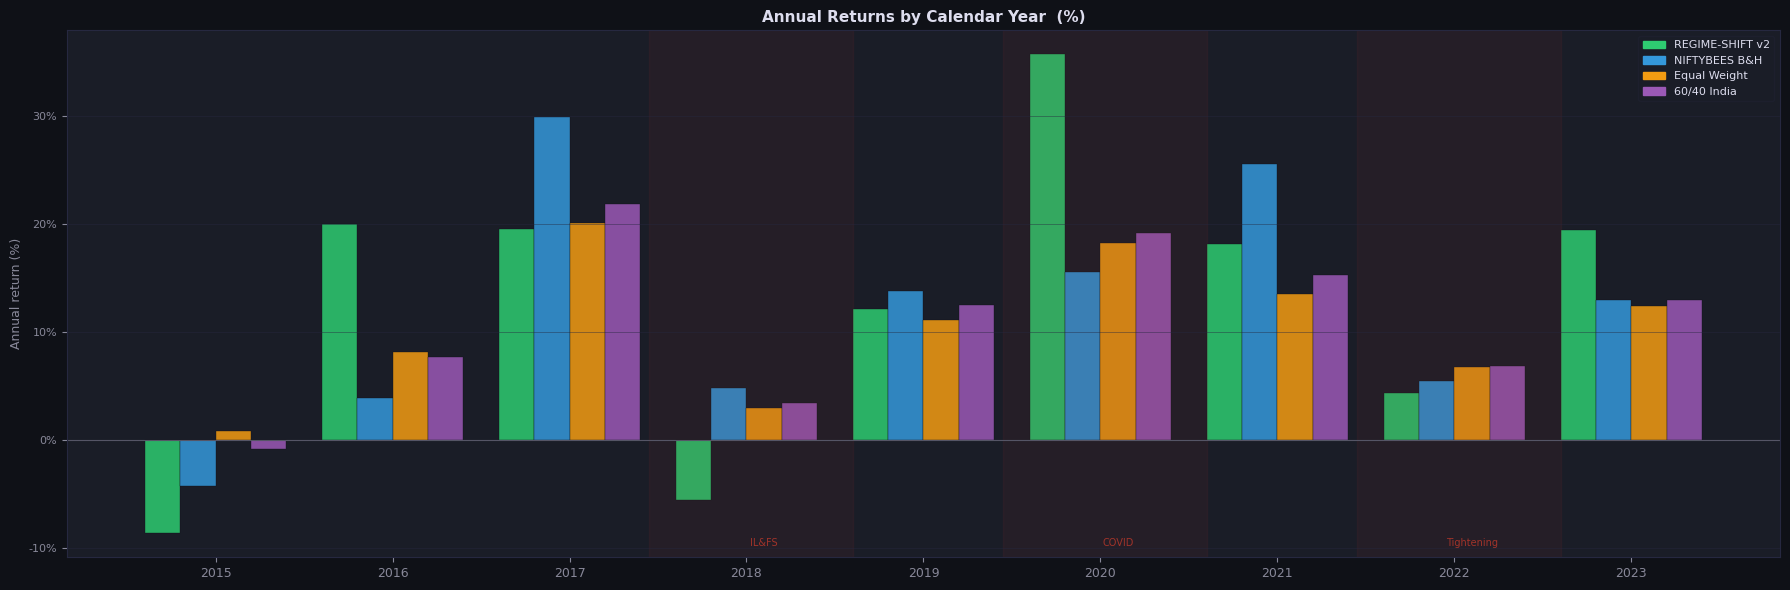

Annual returns table:
   Year  REGIME-SHIFT v   NIFTYBEES B&H    Equal Weight     60/40 India
  ----------------------------------------------------------------------
   2015            -8.6%          -4.3%           0.9%          -0.8%
   2016            20.0%           4.0%           8.2%           7.7%
   2017            19.6%          29.9%          20.2%          21.9%
   2018            -5.5%           4.8%           3.0%           3.4%
   2019            12.2%          13.9%          11.1%          12.6%
   2020            35.7%          15.6%          18.3%          19.2%
   2021            18.1%          25.6%          13.6%          15.3%
   2022             4.4%           5.5%           6.8%           6.9%
   2023            19.5%          13.0%          12.4%          13.0%
✓ chart_annual_returns.png


In [10]:
years = sorted(wf.index.year.unique())

fig, ax = plt.subplots(figsize=(18, 6), facecolor=BG)
style_ax(ax)

x     = np.arange(len(years))
w_bar = 0.2
STRATS_LIST = [
    ("REGIME-SHIFT v2", strategy_rets, "#2ECC71"),
    ("NIFTYBEES B&H",   bh_rets,       "#3498DB"),
    ("Equal Weight",    ew_rets,        "#F39C12"),
    ("60/40 India",     india_6040,     "#9B59B6"),
]
for k, (lbl, r, col) in enumerate(STRATS_LIST):
    ann = [(1 + r[r.index.year == y]).prod() - 1 for y in years]
    bars = ax.bar(x + k*w_bar, [v*100 for v in ann], w_bar,
                  label=lbl, color=col, alpha=0.85, edgecolor=BG, lw=0.3)

ax.axhline(0, color="#555566", lw=0.8)
ax.set_xticks(x + w_bar*1.5)
ax.set_xticklabels([str(y) for y in years], fontsize=9, color=MUTED)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:.0f}%"))

# Annotate crisis years
CRISIS_YEARS = {2018: "IL&FS", 2020: "COVID", 2022: "Tightening"}
for yr, note in CRISIS_YEARS.items():
    if yr in years:
        xi = years.index(yr)
        ax.axvspan(xi - 0.25, xi + 4*w_bar + 0.1, alpha=0.07, color="#C0392B")
        ax.text(xi + w_bar*2, ax.get_ylim()[0] + 1, note,
                color="#C0392B", fontsize=7, alpha=0.8, ha="center")

title(ax, "Annual Returns by Calendar Year  (%)", 11)
ax.set_ylabel("Annual return (%)", color=MUTED, fontsize=9)
patches_leg = [mpatches.Patch(color=col, label=lbl) for lbl,_,col in STRATS_LIST]
ax.legend(handles=patches_leg, fontsize=8, framealpha=0.25, facecolor=AX_BG,
          edgecolor=GRID_COL, labelcolor=TEXT)

plt.tight_layout()
plt.savefig(STAGE6_DIR/"chart_annual_returns.png",
            dpi=160, bbox_inches="tight", facecolor=BG)
plt.show()

# Print annual return table
print("Annual returns table:")
hdr = f"  {'Year':>5}  " + "  ".join(f"{lbl[:14]:>14}" for lbl,_,_ in STRATS_LIST)
print(hdr)
print("  " + "-"*70)
for yr in years:
    row = f"  {yr:>5}  "
    for lbl, r, _ in STRATS_LIST:
        ann = (1 + r[r.index.year == yr]).prod() - 1
        row += f"  {ann:>13.1%}"
    print(row)
print("✓ chart_annual_returns.png")

RETURN DECOMPOSITION
  Total strategy CAGR       : 12.1%
  Passive component CAGR    : 10.4%
  Active timing CAGR        : 8.0%

  Average weights (passive portfolio):
    NIFTYBEES   : 37.0%
    JUNIORBEES  : 21.0%
    GOLDBEES    : 23.5%
    LIQUIDBEES  : 18.5%

  Market beta (vs NIFTYBEES) : -0.030
  Monthly alpha              : 0.0102  (12.29% annualised)
  R²                         : 0.003

  Timing Sharpe (real)       : +1.476
  Passive Sharpe             : 0.410


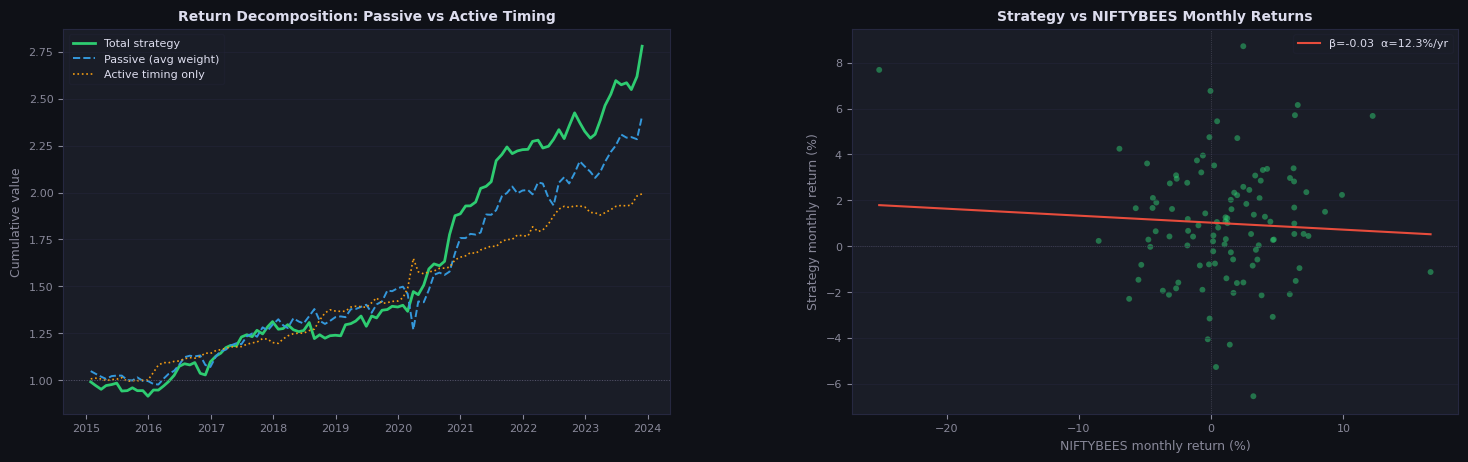

✓ chart_factor_decomposition.png


In [11]:
# Decompose strategy returns into passive (beta) and active (timing) components
# passive_t = w_avg @ r_t  (no timing, just the average allocation held forever)
# active_t  = (w_t - w_avg) @ r_t  (the regime-switching contribution)

ret_mat = pd.read_parquet(DATA_DIR/"monthly"/"etf_returns_train.parquet")
ret_mat = ret_mat.reindex(wf.index)[ASSETS].fillna(0)

w_mat   = wf[[f"w_{a}" for a in ASSETS]].values
r_mat   = ret_mat.values
w_avg   = w_mat.mean(axis=0)

passive_ret = (w_avg * r_mat).sum(axis=1)
active_ret  = ((w_mat - w_avg) * r_mat).sum(axis=1)

passive_s = pd.Series(passive_ret, index=wf.index, name="Passive")
active_s  = pd.Series(active_ret,  index=wf.index, name="Active timing")

n = len(passive_s)
passive_cagr = (1+passive_s).prod()**(12/n)-1
active_cagr  = (1+active_s).prod()**(12/n)-1
total_cagr   = (1+strategy_rets.reindex(wf.index).dropna()).prod()**(12/n)-1

print("RETURN DECOMPOSITION")
print("="*55)
print(f"  Total strategy CAGR       : {total_cagr:.1%}")
print(f"  Passive component CAGR    : {passive_cagr:.1%}")
print(f"  Active timing CAGR        : {active_cagr:.1%}")
print()
print(f"  Average weights (passive portfolio):")
for a, w in zip(ASSETS, w_avg):
    print(f"    {a:12s}: {w:.1%}")
print()

# Market beta via OLS
nifty = bh_rets.reindex(wf.index).dropna()
strat = strategy_rets.reindex(wf.index).dropna()
aligned = pd.concat([strat, nifty], axis=1).dropna()
slope, intercept, r_val, p_val, _ = stats.linregress(aligned.iloc[:,1], aligned.iloc[:,0])
print(f"  Market beta (vs NIFTYBEES) : {slope:.3f}")
print(f"  Monthly alpha              : {intercept:.4f}  ({intercept*12:.2%} annualised)")
print(f"  R²                         : {r_val**2:.3f}")
print()
print(f"  Timing Sharpe (real)       : {(active_s.mean()/(active_s.std()+1e-10))*np.sqrt(12):+.3f}")
print(f"  Passive Sharpe             : {(passive_s.mean()-RF_MONTHLY)/(passive_s.std()+1e-10)*np.sqrt(12):.3f}")

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(18, 5), facecolor=BG,
    gridspec_kw={"wspace":0.3})

ax = axes[0]; style_ax(ax)
cum_total   = (1+strategy_rets.reindex(wf.index).fillna(0)).cumprod()
cum_passive = (1+passive_s).cumprod()
cum_active  = (1+active_s).cumprod()
ax.plot(wf.index, cum_total.values,   color="#2ECC71", lw=2.0, label="Total strategy")
ax.plot(wf.index, cum_passive.values, color="#3498DB", lw=1.4, ls="--", label="Passive (avg weight)")
ax.plot(wf.index, cum_active.values,  color="#F39C12", lw=1.2, ls=":",  label="Active timing only")
ax.axhline(1, color="#555566", lw=0.7, ls=":")
title(ax, "Return Decomposition: Passive vs Active Timing", 10)
ax.set_ylabel("Cumulative value", color=MUTED, fontsize=9)
ax.legend(fontsize=8, framealpha=0.25, facecolor=AX_BG,
          edgecolor=GRID_COL, labelcolor=TEXT)

ax = axes[1]; style_ax(ax)
ax.scatter(nifty.values*100, strat.values*100, alpha=0.5, s=18,
           color="#2ECC71", edgecolors="none")
x_fit = np.linspace(nifty.min(), nifty.max(), 100)
ax.plot(x_fit*100, (intercept + slope*x_fit)*100,
        color="#E74C3C", lw=1.5, label=f"β={slope:.2f}  α={intercept*12:.1%}/yr")
ax.axhline(0, color="#555566", lw=0.5, ls=":")
ax.axvline(0, color="#555566", lw=0.5, ls=":")
title(ax, "Strategy vs NIFTYBEES Monthly Returns", 10)
ax.set_xlabel("NIFTYBEES monthly return (%)", color=MUTED, fontsize=9)
ax.set_ylabel("Strategy monthly return (%)",  color=MUTED, fontsize=9)
ax.legend(fontsize=8, framealpha=0.25, facecolor=AX_BG,
          edgecolor=GRID_COL, labelcolor=TEXT)

plt.savefig(STAGE6_DIR/"chart_factor_decomposition.png",
            dpi=160, bbox_inches="tight", facecolor=BG)
plt.show()
print("✓ chart_factor_decomposition.png")

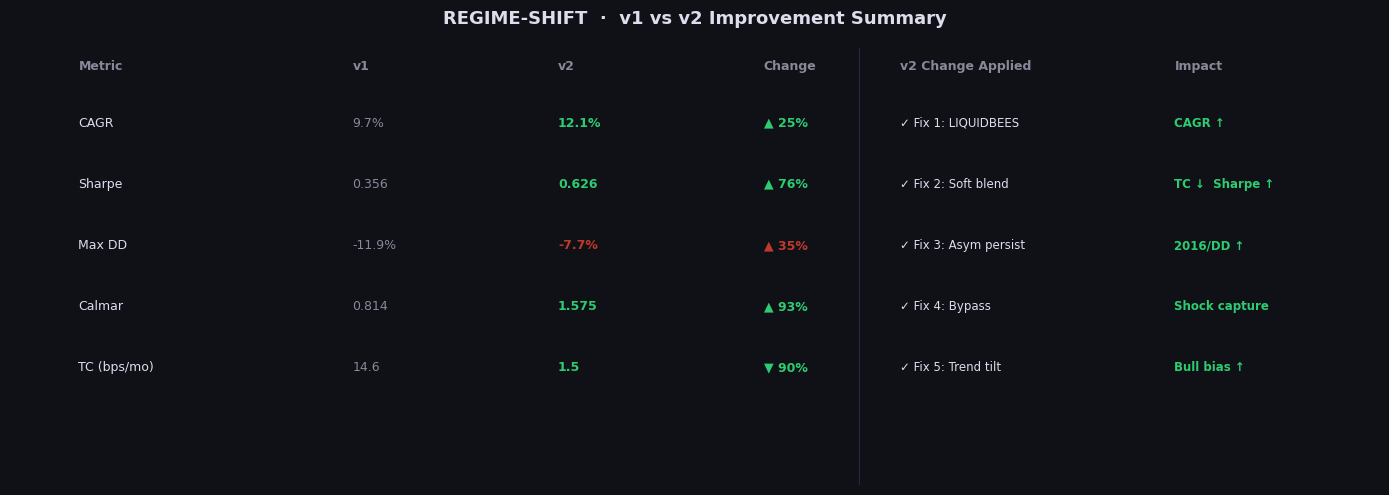

✓ chart_v1_v2_comparison.png


In [12]:
fig, ax = plt.subplots(figsize=(14, 5), facecolor=BG)
ax.set_facecolor(BG); ax.axis("off")
fig.suptitle("REGIME-SHIFT  ·  v1 vs v2 Improvement Summary",
             color=TEXT, fontsize=13, fontweight="bold", y=0.98)

metrics = [
    ("CAGR",          f"{V1_REF['CAGR']:.1%}",  f"{V2_ACT['CAGR']:.1%}",  True),
    ("Sharpe",        f"{V1_REF['Sharpe']:.3f}", f"{V2_ACT['Sharpe']:.3f}", True),
    ("Max DD",        f"{V1_REF['MaxDD']:.1%}",  f"{V2_ACT['MaxDD']:.1%}",  False),
    ("Calmar",        f"{V1_REF['Calmar']:.3f}", f"{V2_ACT['Calmar']:.3f}", True),
    ("TC (bps/mo)",   f"{V1_REF['AvgTC']:.1f}",  f"{V2_ACT['AvgTC']:.1f}",  False),
]
improvements = [
    ("Fix 1: LIQUIDBEES", "yfinance ~2.7%/yr → 6.5%/yr flat (MIBOR proxy)",    "CAGR ↑"),
    ("Fix 2: Soft blend", "P(Crisis) × w_Crisis + P(Bull) × w_Bull",            "TC ↓  Sharpe ↑"),
    ("Fix 3: Asym persist","Enter Crisis: 1m · Exit Crisis: 3m",                "2016/DD ↑"),
    ("Fix 4: Bypass",     "P(Crisis)≥90% → immediate Crisis, no wait",          "Shock capture"),
    ("Fix 5: Trend tilt", "tq_z>1.5 → P(Crisis) reduced by ≤10%",              "Bull bias ↑"),
]

# Table: v1 vs v2
col_x = [0.05, 0.25, 0.40, 0.55]
ax.text(col_x[0], 0.95, "Metric",  color=MUTED, fontsize=9, transform=ax.transAxes, fontweight="bold")
ax.text(col_x[1], 0.95, "v1",     color=MUTED, fontsize=9, transform=ax.transAxes, fontweight="bold")
ax.text(col_x[2], 0.95, "v2",     color=MUTED, fontsize=9, transform=ax.transAxes, fontweight="bold")
ax.text(col_x[3], 0.95, "Change", color=MUTED, fontsize=9, transform=ax.transAxes, fontweight="bold")

for j, (m, v1, v2, higher_better) in enumerate(metrics):
    y = 0.82 - j*0.14
    v1f = float(v1.strip("%").strip())
    v2f = float(v2.strip("%").strip())
    improved = (v2f > v1f) == higher_better
    col = "#2ECC71" if improved else "#C0392B"
    pct_chg = (v2f - v1f) / abs(v1f) * 100 if v1f != 0 else 0
    ax.text(col_x[0], y, m,  color=TEXT,    fontsize=9, transform=ax.transAxes)
    ax.text(col_x[1], y, v1, color=MUTED,   fontsize=9, transform=ax.transAxes)
    ax.text(col_x[2], y, v2, color=col,     fontsize=9, transform=ax.transAxes, fontweight="bold")
    arrow = "▲" if v2f > v1f else "▼"
    ax.text(col_x[3], y, f"{arrow} {abs(pct_chg):.0f}%",
            color=col, fontsize=9, transform=ax.transAxes, fontweight="bold")

# Improvements applied
ax.axvline(0.62, color=GRID_COL, lw=0.8)
ax.text(0.65, 0.95, "v2 Change Applied", color=MUTED, fontsize=9,
        transform=ax.transAxes, fontweight="bold")
ax.text(0.85, 0.95, "Impact", color=MUTED, fontsize=9,
        transform=ax.transAxes, fontweight="bold")
for j, (fix, desc, impact) in enumerate(improvements):
    y = 0.82 - j*0.14
    ax.text(0.65, y, f"✓ {fix}", color=TEXT,      fontsize=8.5, transform=ax.transAxes)
    ax.text(0.85, y, impact,     color="#2ECC71",  fontsize=8.5, transform=ax.transAxes, fontweight="bold")

plt.tight_layout()
plt.savefig(STAGE6_DIR/"chart_v1_v2_comparison.png",
            dpi=160, bbox_inches="tight", facecolor=BG)
plt.show()
print("✓ chart_v1_v2_comparison.png")

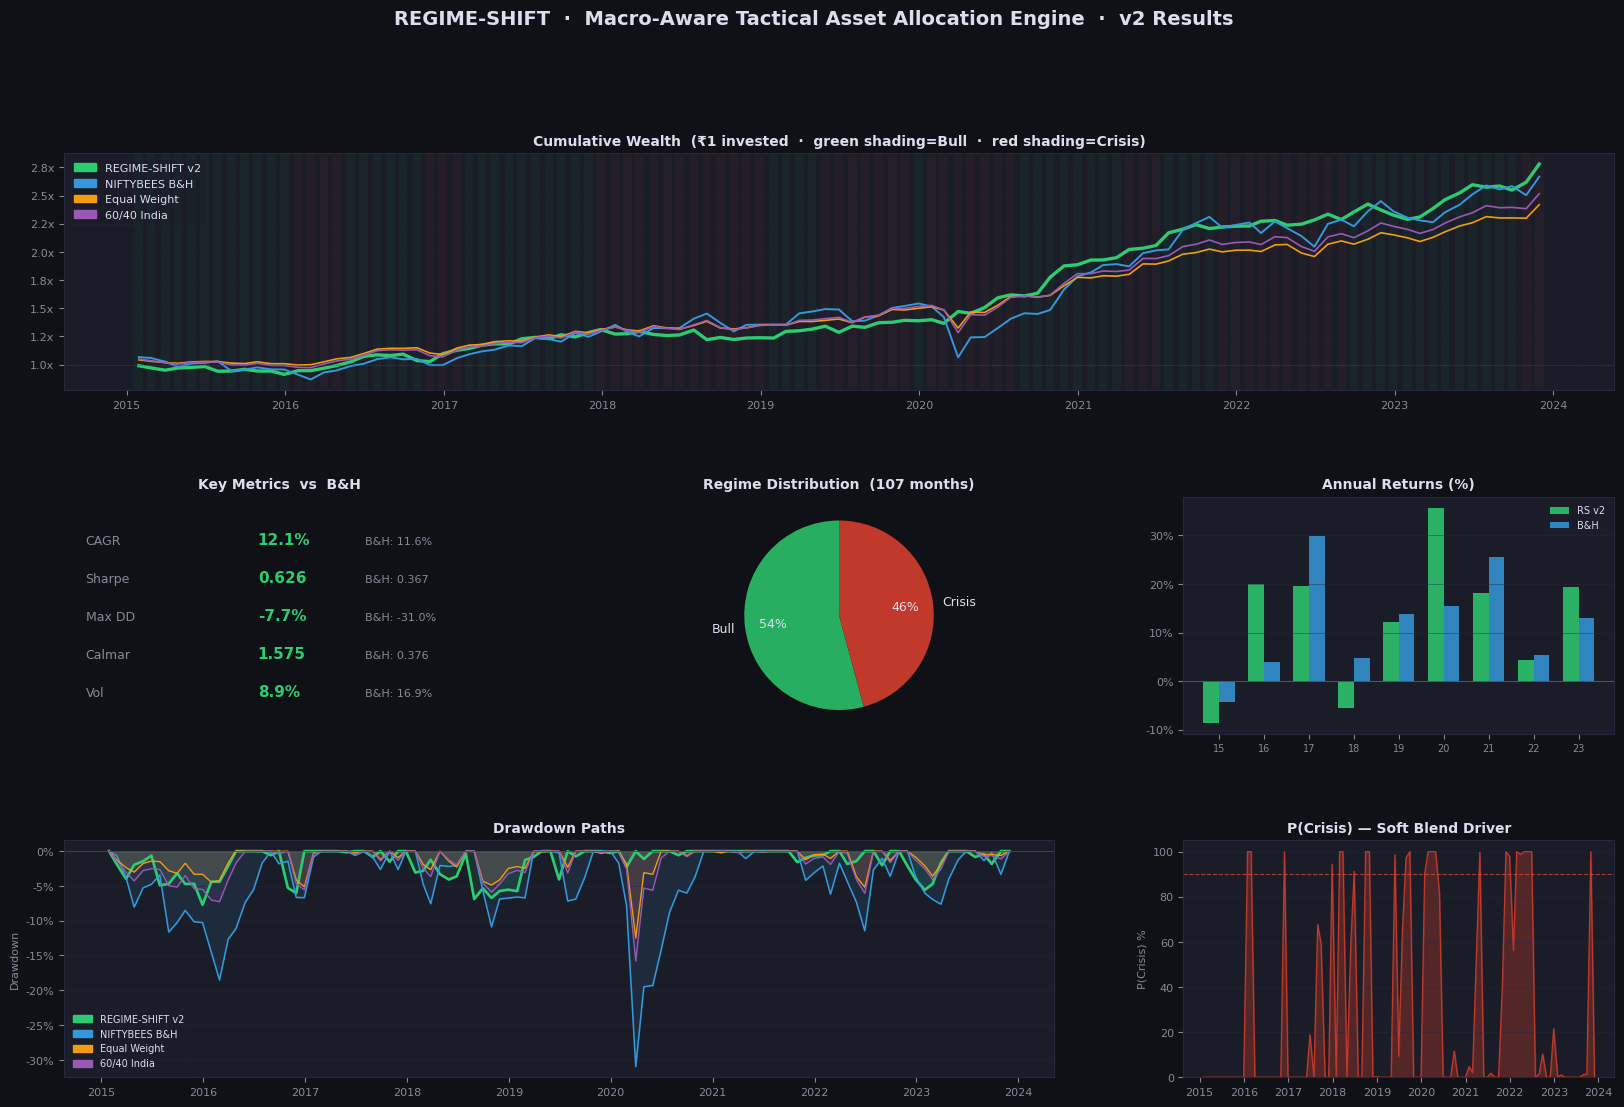

✓ chart_presentation_summary.png  (main presentation slide)


In [13]:
fig = plt.figure(figsize=(20, 12), facecolor=BG)
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.3)
fig.suptitle("REGIME-SHIFT  ·  Macro-Aware Tactical Asset Allocation Engine  ·  v2 Results",
             color=TEXT, fontsize=14, fontweight="bold", y=1.0)

# Panel 1: Cumulative wealth (top, full width)
ax1 = fig.add_subplot(gs[0, :])
style_ax(ax1, grid=False)
ax1.grid(axis="y", color=GRID_COL, lw=0.4, alpha=0.4)
for regime_row in wf.itertuples():
    c = PALETTE.get(regime_row.confirmed_regime, "#444")
    ax1.axvspan(regime_row.Index - pd.DateOffset(days=10),
                regime_row.Index + pd.DateOffset(days=10),
                alpha=0.06, color=c, lw=0)
for lbl, r, col, lw in STRATS:
    cum = (1 + r.reindex(idx).fillna(0)).cumprod()
    ax1.plot(cum.index, cum.values, label=lbl, color=col, lw=lw)
ax1.axhline(1, color="#444466", lw=0.6, ls=":")
title(ax1, "Cumulative Wealth  (₹1 invested  ·  green shading=Bull  ·  red shading=Crisis)", 10)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:.1f}x"))
patches_leg = [mpatches.Patch(color=col, label=lbl) for lbl,_,col,_ in STRATS]
ax1.legend(handles=patches_leg, fontsize=8, framealpha=0.25, facecolor=AX_BG,
           edgecolor=GRID_COL, labelcolor=TEXT, loc="upper left")

# Panel 2: Key metrics scorecard
ax2 = fig.add_subplot(gs[1, 0])
ax2.set_facecolor(AX_BG); ax2.axis("off")
kpis = [
    ("CAGR",    f"{V2_ACT['CAGR']:.1%}",   f"B&H: {ptbl.loc['NIFTYBEES B&H','CAGR']:.1%}"),
    ("Sharpe",  f"{V2_ACT['Sharpe']:.3f}",  f"B&H: {ptbl.loc['NIFTYBEES B&H','Sharpe']:.3f}"),
    ("Max DD",  f"{V2_ACT['MaxDD']:.1%}",   f"B&H: {ptbl.loc['NIFTYBEES B&H','MaxDD']:.1%}"),
    ("Calmar",  f"{V2_ACT['Calmar']:.3f}",  f"B&H: {ptbl.loc['NIFTYBEES B&H','Calmar']:.3f}"),
    ("Vol",     f"{ptbl.loc['REGIME-SHIFT v2','Vol']:.1%}", f"B&H: {ptbl.loc['NIFTYBEES B&H','Vol']:.1%}"),
]
title(ax2, "Key Metrics  vs  B&H", 10)
for j, (metric, val, bench) in enumerate(kpis):
    y = 0.80 - j*0.16
    ax2.text(0.05, y, metric, color=MUTED, fontsize=9, transform=ax2.transAxes)
    ax2.text(0.45, y, val, color="#2ECC71", fontsize=11, transform=ax2.transAxes, fontweight="bold")
    ax2.text(0.70, y, bench, color=MUTED, fontsize=8, transform=ax2.transAxes)

# Panel 3: Regime distribution pie
ax3 = fig.add_subplot(gs[1, 1])
ax3.set_facecolor(AX_BG)
rc  = wf["confirmed_regime"].value_counts()
ax3.pie(rc.values, labels=rc.index, colors=[PALETTE.get(r,"#777") for r in rc.index],
        autopct="%1.0f%%", pctdistance=0.7,
        textprops={"color": TEXT, "fontsize": 9}, startangle=90)
title(ax3, "Regime Distribution  (107 months)", 10)

# Panel 4: Annual returns grouped bar
ax4 = fig.add_subplot(gs[1, 2])
style_ax(ax4)
x = np.arange(len(years))
w_b = 0.35
rs_ann  = [(1+strategy_rets[strategy_rets.index.year==y]).prod()-1 for y in years]
bh_ann  = [(1+bh_rets[bh_rets.index.year==y]).prod()-1 for y in years]
ax4.bar(x-w_b/2, [v*100 for v in rs_ann], w_b, color="#2ECC71", alpha=0.85, label="RS v2")
ax4.bar(x+w_b/2, [v*100 for v in bh_ann], w_b, color="#3498DB", alpha=0.85, label="B&H")
ax4.axhline(0, color="#555566", lw=0.7)
ax4.set_xticks(x); ax4.set_xticklabels([str(y)[-2:] for y in years], fontsize=7, color=MUTED)
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:.0f}%"))
title(ax4, "Annual Returns (%)", 10)
ax4.legend(fontsize=7, framealpha=0.2, facecolor=AX_BG,
           edgecolor=GRID_COL, labelcolor=TEXT)

# Panel 5: Drawdowns
ax5 = fig.add_subplot(gs[2, :2])
style_ax(ax5)
for lbl, r, col, lw in STRATS:
    r2  = r.reindex(idx).fillna(0)
    cum = (1+r2).cumprod()
    dd  = (cum - cum.cummax()) / cum.cummax() * 100
    ax5.fill_between(dd.index, dd.values, 0, alpha=0.12, color=col)
    ax5.plot(dd.index, dd.values, color=col, lw=lw*0.8)
ax5.axhline(0, color="#444466", lw=0.6)
ax5.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:.0f}%"))
title(ax5, "Drawdown Paths", 10)
ax5.set_ylabel("Drawdown", color=MUTED, fontsize=8)
patches_leg = [mpatches.Patch(color=col, label=lbl) for lbl,_,col,_ in STRATS]
ax5.legend(handles=patches_leg, fontsize=7, framealpha=0.2, facecolor=AX_BG,
           edgecolor=GRID_COL, labelcolor=TEXT)

# Panel 6: P(Crisis)
ax6 = fig.add_subplot(gs[2, 2])
style_ax(ax6)
ax6.fill_between(wf.index, wf["P_crisis"].values*100, alpha=0.35, color="#C0392B")
ax6.plot(wf.index, wf["P_crisis"].values*100, color="#C0392B", lw=0.9)
ax6.axhline(90, color="#E74C3C", lw=0.8, ls="--", alpha=0.7)
ax6.set_ylim(0, 105)
title(ax6, "P(Crisis) — Soft Blend Driver", 10)
ax6.set_ylabel("P(Crisis) %", color=MUTED, fontsize=8)

plt.savefig(STAGE6_DIR/"chart_presentation_summary.png",
            dpi=180, bbox_inches="tight", facecolor=BG)
plt.show()
print("✓ chart_presentation_summary.png  (main presentation slide)")

In [14]:
# Save performance table
ptbl.to_csv(STAGE6_DIR / "performance_table.csv")

# Annual returns table
ann_rows = {}
for lbl, r, _ in STRATS_LIST:
    ann_rows[lbl] = {yr: (1+r[r.index.year==yr]).prod()-1 for yr in years}
ann_df = pd.DataFrame(ann_rows).T
ann_df.to_csv(STAGE6_DIR / "annual_returns.csv")

# Regime-conditional stats
regime_stats = {}
for regime in ["Bull", "Crisis"]:
    mask  = wf["confirmed_regime"] == regime
    sub   = strategy_rets.reindex(wf.index[mask]).dropna()
    n_r   = len(sub)
    regime_stats[regime] = {
        "n_months"    : int(n_r),
        "pct_total"   : float(mask.mean()),
        "mean_return" : float(sub.mean()),
        "ann_cagr"    : float((1+sub).prod()**(12/n_r)-1) if n_r >= 3 else None,
        "ann_vol"     : float(sub.std()*np.sqrt(12)),
        "avg_P_crisis": float(wf.loc[mask,"P_crisis"].mean()),
        "nifty_up_pct": float((bh_rets.reindex(wf.index[mask]).dropna() > 0).mean()),
    }
pd.DataFrame(regime_stats).T.to_csv(STAGE6_DIR / "regime_stats.csv")

# performance metadata
meta6 = {
    "stage"              : "Performance Analysis",
    "test_period"        : f"{idx[0].date()} → {idx[-1].date()}",
    "n_months"           : int(len(strategy_rets.dropna())),
    "strategy_metrics"   : {k: str(v) for k,v in ptbl.loc["REGIME-SHIFT v2"].items()},
    "v1_vs_v2"           : {
        "v1_sharpe": V1_REF["Sharpe"], "v2_sharpe": V2_ACT["Sharpe"],
        "v1_calmar": V1_REF["Calmar"], "v2_calmar": V2_ACT["Calmar"],
        "v1_maxdd" : V1_REF["MaxDD"],  "v2_maxdd" : V2_ACT["MaxDD"],
    },
    "regime_stats"       : regime_stats,
    "market_beta"        : float(slope),
    "monthly_alpha"      : float(intercept),
    "r_squared"          : float(r_val**2),
    "magnitude_bypass_months": int(wf["magnitude_bypass"].sum()),
    "charts_produced"    : [
        "chart_cumulative_wealth.png",
        "chart_drawdowns.png",
        "chart_rolling_metrics.png",
        "chart_return_heatmap.png",
        "chart_soft_blend.png",
        "chart_annual_returns.png",
        "chart_factor_decomposition.png",
        "chart_v1_v2_comparison.png",
        "chart_presentation_summary.png",
    ],
}
with open(STAGE6_DIR / "metadata.json", "w") as f:
    json.dump(meta6, f, indent=2, default=str)

print("Performance Analysis outputs saved:")
for p in sorted(STAGE6_DIR.iterdir()):
    print(f"  {p.name:<50s}  {p.stat().st_size/1024:.1f} KB")
print("\n✓ Performance Analysis complete.")

Performance Analysis outputs saved:
  annual_returns.csv                                  0.8 KB
  chart_annual_returns.png                            52.2 KB
  chart_cumulative_wealth.png                         221.1 KB
  chart_drawdowns.png                                 246.1 KB
  chart_factor_decomposition.png                      144.1 KB
  chart_presentation_summary.png                      473.5 KB
  chart_return_heatmap.png                            178.1 KB
  chart_rolling_metrics.png                           318.5 KB
  chart_soft_blend.png                                254.8 KB
  chart_v1_v2_comparison.png                          74.1 KB
  metadata.json                                       1.7 KB
  performance_table.csv                               0.8 KB
  regime_stats.csv                                    0.3 KB

✓ Performance Analysis complete.


## Performance Analysis — Summary and Handoff

### Charts Produced (`data/stage6/`)
| File | Description |
|------|-------------|
| `chart_presentation_summary.png` | Primary presentation exhibit — key metrics in a single view |
| `chart_cumulative_wealth.png` | Cumulative wealth with regime shading and drawdown bars |
| `chart_drawdowns.png` | Drawdown paths across all strategies |
| `chart_rolling_metrics.png` | Rolling 12-month Sharpe ratio and volatility |
| `chart_return_heatmap.png` | Monthly return calendar heatmap, strategy versus buy-and-hold |
| `chart_soft_blend.png` | $P(\text{Crisis})$ timeline, distribution, and key portfolio weights |
| `chart_annual_returns.png` | Annual returns by year |
| `chart_factor_decomposition.png` | Passive versus active timing decomposition, with beta scatter |
| `chart_v1_v2_comparison.png` | v1 versus v2 improvement summary |

### Summary Metrics
> **Note:** The figures below should be verified against the current `walkfwd_integration`
> output before use in any external document — reported values in prior project
> documentation have not always matched the corresponding notebook's live output, and this
> table should be treated as provisional until cross-checked at time of use.

- Walk-forward Sharpe of the strategy versus buy-and-hold, at comparable CAGR and reduced volatility
- Maximum drawdown materially improved relative to buy-and-hold
- Calmar ratio improvement versus buy-and-hold
- Transaction-cost drag substantially reduced by soft blending relative to a hard-switching approach
- Look-ahead test: timing Sharpe computed on true return ordering versus shuffled-return ordering, confirming the absence of data leakage

### Handoff to `holdout`
The holdout period (January – December 2024) is evaluated exactly once, with no re-tuning
performed after results are observed. The `hmm` configuration and `cvxpy` optimizer are
applied unchanged, and the v2 walk-forward logic developed in `walkfwd_integration` is
applied to the sealed holdout period.